# 17 — Exact shape gradients and shape optimization

Notebook 10 trained a surrogate and took `dJ/dx` through *its* forward pass:
cheap, and only as accurate as the surrogate. This notebook takes the other
path — the **discretely exact** shape gradient of the real finite-element
solve, and drives an actual shape optimization with it.

The adjoint identity `dJ/dθ = ∂J/∂θ + λᵀ ∂b/∂θ` (with `Kᵀλ = ∂J/∂u`) has
shipped for a while, but `ComputeParameterSensitivities` evaluates `∂b/∂θ`
by re-assembling the **whole** residual twice per parameter. A design
surface of *N* nodes therefore costs `6N` global assemblies — fine for a
handful of scalars, hopeless for a shape.

`ComputeShapeSensitivityField` exploits the structure the global path
throws away: moving node *k* perturbs only the entities **adjacent** to
*k*, so `∂b/∂X` is sparse. Perturbing each entity's own nodes and
re-evaluating only *that entity's* local right-hand side gives `dJ/dX` at
every node for a cost linear in the mesh.

Then `ComputeControlSensitivities` pushes that nodal field back through the
differentiable deformers, so the gradient lands on the design parameters
you actually control.

In [1]:
import sys
import time
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import KratosMultiphysics as Kratos
Kratos.Logger.GetDefaultOutput().SetSeverity(Kratos.Logger.Severity.WARNING)
from KratosMultiphysics.PhysicsNeMoApplication.physics import differentiable_residual
from KratosMultiphysics.PhysicsNeMoApplication.physics import sensitivity_utils
from KratosMultiphysics.PhysicsNeMoApplication.bridges.mesh_bridge import deformation

# the in-memory solver cases live with the tests, found by walking up rather
# than by a path relative to the process' working directory: a notebook has no
# __file__, and cwd is only the notebook's own directory by Jupyter convention
def FindCases():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "tests" / "kratos_solver_cases"
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        f"could not find tests/kratos_solver_cases above {Path.cwd()}")


CASES = FindCases()
sys.path.insert(0, str(CASES))
import thermal_case

# an FFD lattice spanning the unit square; the z extent is non-degenerate on
# purpose, since the mesh's own bounding box is flat in z
ORIGIN = [0.0, 0.0, -0.5]
EXTENT = [1.0, 1.0, 1.0]
print("cases from:", CASES)

import contextlib
import os


@contextlib.contextmanager
def Quiet():
    """Silences Kratos' solver chatter around a block.

    WARNING is Kratos' highest severity, so its own internal deprecation
    notices cannot be turned off through the logger - and because the
    logging happens in C++, contextlib.redirect_stdout never sees it. The
    file descriptor itself has to be redirected. Python exceptions are
    unaffected, so nothing real is hidden.
    """
    saved = os.dup(1)
    with open(os.devnull, "w") as null:
        os.dup2(null.fileno(), 1)
    try:
        yield
    finally:
        os.dup2(saved, 1)
        os.close(saved)

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
cases from: /tmp/claude-1000/-home-vicente-src-Kratos/b64f5222-475d-44c4-8fcd-1386c3c04dbc/scratchpad/nbwork_b/applications/PhysicsNeMoApplication/tests/kratos_solver_cases


## A real solve, and a design objective

`thermal_case` is a unit square with a uniform heat source, conductivity 2
and `T = 0` on all four edges — ConvectionDiffusion's stationary heat
equation. The objective is the **total nodal temperature**

    J = Σ T_i

which responds to the domain's shape: a smaller or differently-proportioned
domain sheds heat differently.

The case data — including *which* nodes are Dirichlet — is applied when the
analysis is built, on the undeformed mesh. Deforming afterwards therefore
keeps the boundary set fixed, which is exactly what the adjoint assumes.

121 nodes, 200 elements
J0 = 1.662003


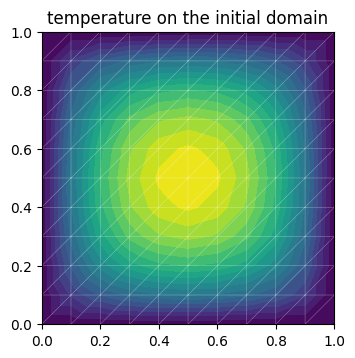

In [2]:
def Solve(control=None, reference=None, divisions=10):
    """Solves the thermal case, optionally on an FFD-deformed mesh."""
    model = Kratos.Model()
    with Quiet():
        analysis = thermal_case.CreateThermalAnalysis(
            model, conductivity=2.0, heat_flux=1.0, divisions=divisions)
        analysis.Initialize()
    model_part = model["ThermalModelPart"]

    if control is not None:
        points = torch.as_tensor(reference, dtype=torch.float64)
        deformed = deformation.DeformPoints(
            points, torch.as_tensor(control, dtype=torch.float64), "ffd",
            origin=ORIGIN, extent=EXTENT).numpy()
        for node, position in zip(model_part.Nodes, deformed):
            node.X0, node.Y0, node.Z0 = (float(position[0]), float(position[1]),
                                         float(position[2]))
            node.X, node.Y, node.Z = node.X0, node.Y0, node.Z0

    with Quiet():
        analysis.RunSolutionLoop()
    return model, model_part


def Objective(model_part):
    return sum(node.GetSolutionStepValue(Kratos.TEMPERATURE)
               for node in model_part.Nodes)


def MeshArrays(model_part):
    """(points, triangles, temperature) for plotting."""
    points = numpy.array([[n.X, n.Y] for n in model_part.Nodes])
    rows = {n.Id: i for i, n in enumerate(model_part.Nodes)}
    triangles = numpy.array([[rows[e.GetGeometry()[i].Id] for i in range(3)]
                             for e in model_part.Elements])
    temperature = numpy.array([n.GetSolutionStepValue(Kratos.TEMPERATURE)
                               for n in model_part.Nodes])
    return points, triangles, temperature


model, model_part = Solve()
reference = numpy.array([[n.X0, n.Y0, n.Z0] for n in model_part.Nodes])
J0 = Objective(model_part)
print(f"{model_part.NumberOfNodes()} nodes, {model_part.NumberOfElements()} elements")
print(f"J0 = {J0:.6f}")

points, triangles, temperature = MeshArrays(model_part)
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.tricontourf(mtri.Triangulation(points[:, 0], points[:, 1], triangles),
               temperature, levels=20)
ax.triplot(mtri.Triangulation(points[:, 0], points[:, 1], triangles),
           color="w", linewidth=0.3, alpha=0.5)
ax.set_aspect("equal"); ax.set_title("temperature on the initial domain")
plt.show()

## `dJ/dX` at every node, from one pass

`ComputeShapeSensitivityField` needs the same three things as the scalar
path — an assembler and DOF map at the **solved** state, and `∂J/∂u`. For
`J = Σ T_i` that gradient is simply a vector of ones.

The result is `(n_nodes, 3)`, in `model_part.Nodes` order — the same order
`graph_bridge.NodePositions` and every other gather in this application
uses. Below it is checked against the old per-coordinate path on a few
coordinates: the two agree to roughly ten digits.

In [3]:
def ShapeField(model_part, fd_step=1e-6, **kwargs):
    assembler = differentiable_residual.TangentAssembler(model_part)
    dof_map = differentiable_residual.DofFieldMap(
        assembler, [("TEMPERATURE", "node_historical")])
    dJ_du = numpy.ones(dof_map.n_equations)          # J = sum of temperatures
    field = sensitivity_utils.ComputeShapeSensitivityField(
        assembler, dof_map, dJ_du, fd_step=fd_step, **kwargs)
    return assembler, dof_map, dJ_du, field


assembler, dof_map, dJ_du, field = ShapeField(model_part)
print("field shape:", field.shape, " max |dJ/dX| =", numpy.abs(field).max())

# the old path, on three coordinates only - it costs two full residual
# re-assemblies each, which is exactly why it does not scale
rows = {n.Id: i for i, n in enumerate(model_part.Nodes)}
axes = (("X0", "X"), ("Y0", "Y"), ("Z0", "Z"))
sample = [(n.Id, axis) for n in list(model_part.Nodes)[40:43] for axis in (0,)]

appliers = {}
for node_id, axis in sample:
    node = model_part.GetNode(node_id)
    def MakeApplier(node=node, axis=axis):
        def Apply(value):
            for attribute in axes[axis]:
                setattr(node, attribute, value)
        return Apply
    appliers[(node_id, axis)] = (MakeApplier(), getattr(node, axes[axis][0]))

reference_values = sensitivity_utils.ComputeParameterSensitivities(
    assembler, dof_map, dJ_du, appliers, fd_step=1e-6)
for (node_id, axis), value in reference_values.items():
    got = field[rows[node_id], axis]
    relative = abs(got - value) / abs(value)
    print(f"node {node_id} axis {axis}:  field {got:+.10e}   "
          f"global path {value:+.10e}   rel {relative:.2e}")
    # the point of the element-local field is that it *is* the number the
    # global path computes, not an approximation of it
    assert relative < 1e-6, f"field disagrees with the global path: rel {relative:.2e}"

field shape: (121, 3)  max |dJ/dX| = 0.46689190030841854
node 41 axis 0:  field +4.3235439737e-02   global path +4.3235439736e-02   rel 9.02e-12
node 42 axis 0:  field +3.1637369414e-02   global path +3.1637369417e-02   rel 9.05e-11
node 43 axis 0:  field +1.4938555986e-02   global path +1.4938555986e-02   rel 5.89e-12


## When it pays off

The element-local pass is **not** free: it is a Python loop, and each entity
costs `nodes × 3 × 2` local right-hand sides. What it buys is that this cost
is *linear in the mesh* and independent of how many design parameters you
have, whereas the global path pays a full assembly per parameter.

So there is a crossover, and it is worth measuring rather than assuming.
Below, the whole-mesh field is timed against what the global path would cost
to produce the same information (`2 × 3N` residual assemblies).

In [4]:
print(f"{'elements':>9} {'field':>9} {'global path':>12} {'speedup':>9}")
for divisions in (10, 20, 30, 40):
    aux_model = Kratos.Model()
    with Quiet():
        aux = thermal_case.CreateThermalAnalysis(
            aux_model, conductivity=2.0, heat_flux=1.0, divisions=divisions)
        aux.Run()
    part = aux_model["ThermalModelPart"]
    aux_assembler = differentiable_residual.TangentAssembler(part)
    aux_map = differentiable_residual.DofFieldMap(
        aux_assembler, [("TEMPERATURE", "node_historical")])
    ones = numpy.ones(aux_map.n_equations)

    for _ in range(3):                       # warm the assembly buffers
        numpy.array(aux_assembler.ComputeResidualVector(), copy=True)
    start = time.perf_counter()
    for _ in range(20):
        numpy.array(aux_assembler.ComputeResidualVector(), copy=True)
    per_assembly = (time.perf_counter() - start) / 20

    start = time.perf_counter()
    sensitivity_utils.ComputeShapeSensitivityField(
        aux_assembler, aux_map, ones, fd_step=1e-6)
    elapsed = time.perf_counter() - start

    global_cost = 2 * 3 * part.NumberOfNodes() * per_assembly
    print(f"{part.NumberOfElements():9d} {elapsed:8.3f}s {global_cost:11.3f}s "
          f"{global_cost / elapsed:8.1f}x")

 elements     field  global path   speedup
      200    0.045s       0.154s      3.4x


      800    0.127s       1.293s     10.1x


     1800    0.270s       3.861s     14.3x


     3200    0.533s      16.684s     31.3x


The absolute times on the two smallest meshes are noisy — they are
fractions of a second, and thread scheduling dominates — but the trend is
the real point: the margin **grows with the mesh**, because the global
path's cost per parameter grows with the element count while the local
pass's does not. On a 3-D structural mesh the same comparison measured
roughly 100× at 24k elements.

The local pass is not free, and on a small enough mesh the Python loop's
per-entity overhead can lose outright; it is a structural win, not a
universal one.

Here is the field itself. The arrows point in the direction that *increases*
total temperature; the optimizer will move against them.

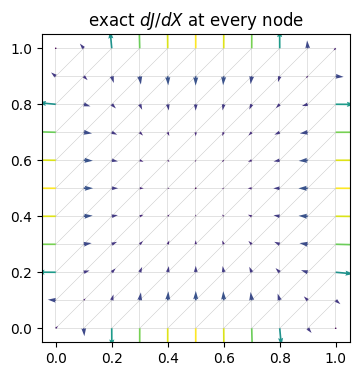

In [5]:
interior = numpy.array([1e-9 < n.X0 < 1 - 1e-9 and 1e-9 < n.Y0 < 1 - 1e-9
                        for n in model_part.Nodes])
fig, ax = plt.subplots(figsize=(4.6, 4.0))
ax.triplot(mtri.Triangulation(points[:, 0], points[:, 1], triangles),
           color="0.8", linewidth=0.4)
ax.quiver(points[:, 0], points[:, 1], field[:, 0], field[:, 1],
          numpy.hypot(field[:, 0], field[:, 1]), cmap="viridis", scale=4.0)
ax.set_aspect("equal"); ax.set_title(r"exact $dJ/dX$ at every node")
plt.show()

## From nodes to design parameters

A design is not `3N` free coordinates — it is a handful of control
parameters. `ComputeControlSensitivities` applies the deformation's chain
rule to the nodal field:

    dJ/d(control) = (dX/d(control))ᵀ · (dJ/dX)

evaluated as a vector-Jacobian product through the shipped differentiable
deformers, so nothing is finite-differenced a second time. Here the design
is a 2×2×2 **free-form-deformation** lattice over the square.

The check below is the honest one: compare against finite differences that
perturb a lattice entry, deform the mesh with that same deformer, and
**re-solve the finite-element problem**.

In [6]:
control = numpy.zeros((2, 2, 2, 3))
control_gradient = sensitivity_utils.ComputeControlSensitivities(
    field, reference, control, "ffd", origin=ORIGIN, extent=EXTENT)
print("control gradient shape:", control_gradient.shape)

step = 1e-5
for entry in ((1, 0, 0, 0), (1, 1, 0, 1)):
    plus, minus = control.copy(), control.copy()
    plus[entry] += step
    minus[entry] -= step
    _, part_plus = Solve(plus, reference)
    _, part_minus = Solve(minus, reference)
    finite_difference = (Objective(part_plus) - Objective(part_minus)) / (2 * step)
    got = control_gradient[entry]
    relative = abs(got - finite_difference) / abs(finite_difference)
    print(f"lattice{entry}:  chain rule {got:+.8e}   re-solve FD {finite_difference:+.8e}   "
          f"rel {relative:.2e}")
    assert relative < 1e-6, (
        f"chain rule disagrees with the re-solve FD: rel {relative:.2e}")

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


control gradient shape: (2, 2, 2, 3)
lattice(1, 0, 0, 0):  chain rule +4.16273368e-01   re-solve FD +4.16273368e-01   rel 1.15e-10
lattice(1, 1, 0, 1):  chain rule +3.95461382e-01   re-solve FD +3.95461382e-01   rel 2.65e-11


## Gradient descent on the shape

With an exact gradient the optimization itself is unremarkable — which is
the point. The target is 75 % of the initial total temperature, and the
objective is a least-squares match

    F(control) = (J(control) − J*)²,     dF/d(control) = 2 (J − J*) · dJ/d(control)

so it converges onto the target instead of running away. Each iteration is
a full solve, a full adjoint, and one field pass. The lattice's
z-components are zeroed to keep the deformation in the plane the 2-D solver
lives in.

In [7]:
TARGET = 0.75 * J0
LEARNING_RATE = 0.1

control = numpy.zeros((2, 2, 2, 3))
history = []
for iteration in range(20):
    _, part = Solve(control, reference) if iteration else (model, model_part)
    value = Objective(part)
    history.append(value)

    _, _, _, iteration_field = ShapeField(part)
    gradient = sensitivity_utils.ComputeControlSensitivities(
        iteration_field, reference, control, "ffd", origin=ORIGIN, extent=EXTENT)
    gradient[..., 2] = 0.0                      # keep the deformation planar
    control = control - LEARNING_RATE * 2.0 * (value - TARGET) * gradient

_, final_part = Solve(control, reference)
history.append(Objective(final_part))
print(f"J: {history[0]:.6f} -> {history[-1]:.6f}   target {TARGET:.6f}")
print(f"largest control displacement: {numpy.abs(control).max():.4f}")

J: 1.662003 -> 1.246512   target 1.246503
largest control displacement: 0.0702


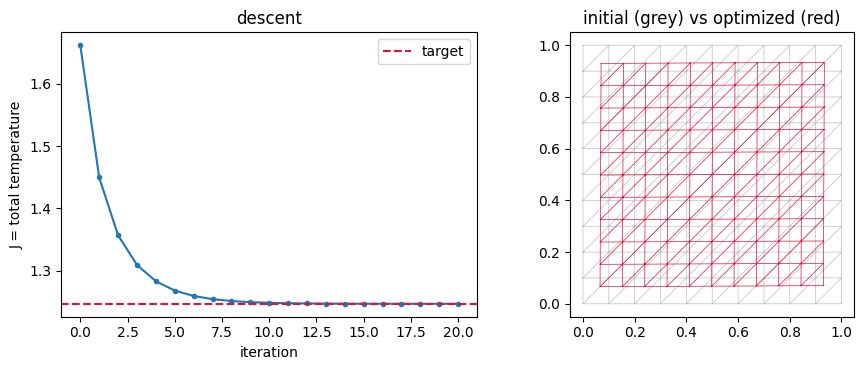

In [8]:
final_points, final_triangles, final_temperature = MeshArrays(final_part)

fig, (left, right) = plt.subplots(1, 2, figsize=(9.4, 3.8))
left.plot(history, marker="o", markersize=3)
left.axhline(TARGET, color="crimson", linestyle="--", label="target")
left.set_xlabel("iteration"); left.set_ylabel("J = total temperature")
left.set_title("descent"); left.legend()

right.triplot(mtri.Triangulation(points[:, 0], points[:, 1], triangles),
              color="0.75", linewidth=0.5)
right.triplot(mtri.Triangulation(final_points[:, 0], final_points[:, 1],
                                 final_triangles),
              color="crimson", linewidth=0.5)
right.set_aspect("equal")
right.set_title("initial (grey) vs optimized (red)")
plt.tight_layout(); plt.show()

### Initial and optimized designs, with their temperature fields

The same two meshes as mesh-aware renders through the core pyvista bridge, coloured by the solved `TEMPERATURE` - the objective is its sum, which the descent reduced to the target.

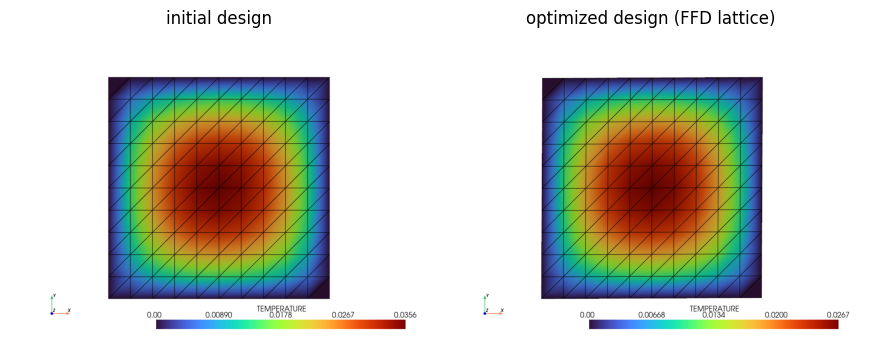

In [9]:
from KratosMultiphysics import pyvista_utilities as pv_utils

img_initial = pv_utils.ScreenshotModelPart(model_part, filename=None, name=Kratos.TEMPERATURE, label="TEMPERATURE", cmap="turbo")
img_final = pv_utils.ScreenshotModelPart(final_part, filename=None, name=Kratos.TEMPERATURE, label="TEMPERATURE", cmap="turbo")
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.0))
for ax, (img, title) in zip(numpy.atleast_1d(axes), [(img_initial, 'initial design'), (img_final, 'optimized design (FFD lattice)')]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); Path("output").mkdir(exist_ok=True); plt.savefig('output/shape_designs.png', dpi=120, bbox_inches="tight"); plt.show()


## Two caveats worth stating

**The mesh must survive.** Nothing above prevents the optimizer from folding
elements; `mesh_bridge.deformation.RegularizationEnergy(..., "inversion")`
exists precisely as a penalty term for that, and notebook 02 shows
`MeshMovingApplication` smoothing a boundary displacement into the interior
without inverting cells.

**Where the interior comes from matters.** Here the FFD deformer moves
*every* node, so `dX/d(control)` is exactly the deformer's Jacobian and the
chain rule above is exact. If instead you move only the boundary and let a
mesh-motion **solver** place the interior, then `dX_interior/d(control)`
runs through that solve too, and neglecting it — as is common practice —
makes the gradient approximate. That is a modelling choice, not a detail:
worth making deliberately rather than by accident.